# Healthcare Cost and Length-of-Stay Analysis

## Objective
This notebook presents a descriptive analysis of a healthcare dataset with a focus on patient demographics, hospital billing, admission trends, insurance patterns, and length of stay..


## 1. Setup
This section imports the libraries used for data preparation, numerical summaries, and visualization.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

BLUE_1 = "#dbeafe"
BLUE_2 = "#bfdbfe"
BLUE_3 = "#93c5fd"
BLUE_4 = "#60a5fa"
BLUE_5 = "#3b82f6"


## 2. Load the Dataset
The dataset is loaded and previewed to confirm the available variables and overall structure.


In [2]:
df = pd.read_csv("healthcare_dataset.csv")
df.head()


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,"18,856.28",328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,"33,643.33",265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,"27,955.10",205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,"37,909.78",450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,"14,238.32",458,Urgent,2022-10-09,Penicillin,Abnormal


## 3. Initial Data Quality Check
Before analysis, we check the data types, completeness, and basic data quality indicators.


In [3]:
data_quality = pd.DataFrame({
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isna().sum(),
    "Non-Null Count": df.notna().sum(),
})
data_quality


,Data Type,Missing Values,Non-Null Count
Name,object,0,55500
Age,int64,0,55500
Gender,object,0,55500
Blood Type,object,0,55500
Medical Condition,object,0,55500
Date of Admission,object,0,55500
Doctor,object,0,55500
Hospital,object,0,55500
Insurance Provider,object,0,55500
Billing Amount,float64,0,55500


## 4. Data Preparation
Date columns are converted to datetime format, and new fields are created to support analysis. These include `Length of Stay`, `Admission Month`, and `Admission Year`.


In [4]:
df["Date of Admission"] = pd.to_datetime(df["Date of Admission"])
df["Discharge Date"] = pd.to_datetime(df["Discharge Date"])
df["Length of Stay"] = (df["Discharge Date"] - df["Date of Admission"]).dt.days
df["Admission Month"] = df["Date of Admission"].dt.to_period("M").astype(str)
df["Admission Year"] = df["Date of Admission"].dt.year

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

df = df.drop_duplicates()
df.head()


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay,Admission Month,Admission Year
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,"18,856.28",328,Urgent,2024-02-02,Paracetamol,Normal,2,2024-01,2024
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,"33,643.33",265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6,2019-08,2019
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,"27,955.10",205,Emergency,2022-10-07,Aspirin,Normal,15,2022-09,2022
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,"37,909.78",450,Elective,2020-12-18,Ibuprofen,Abnormal,30,2020-11,2020
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,"14,238.32",458,Urgent,2022-10-09,Penicillin,Abnormal,20,2022-09,2022


## 5. Output Directory
Charts generated in this notebook are saved into a `plots` folder inside this project directory.


In [5]:
OUTPUT_DIR = Path("plots")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## 6. Plotting Helpers
These helper functions keep the visual style consistent. The bar charts place categories on the x-axis and values on the y-axis.


In [6]:
def save_vertical_bar_plot(series: pd.Series, title: str, xlabel: str, ylabel: str, filename: str, color: str) -> None:
    output_file = OUTPUT_DIR / filename

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x=series.index, y=series.values, color=color)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=30, ha="right")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)

    plt.tight_layout()
    plt.savefig(output_file, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


def save_count_bar_plot(series: pd.Series, title: str, xlabel: str, ylabel: str, filename: str, color: str) -> None:
    output_file = OUTPUT_DIR / filename

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x=series.index, y=series.values, color=color)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=30, ha="right")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f", padding=3, fontsize=9)

    plt.tight_layout()
    plt.savefig(output_file, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


def save_line_plot(data: pd.DataFrame, x_col: str, y_col: str, title: str, xlabel: str, ylabel: str, filename: str, color: str) -> None:
    output_file = OUTPUT_DIR / filename

    plt.figure(figsize=(12, 6))
    plt.plot(data[x_col], data[y_col], marker="o", linewidth=2.5, color=color)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(output_file, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


def save_heatmap(data: pd.DataFrame, title: str, filename: str) -> None:
    output_file = OUTPUT_DIR / filename

    plt.figure(figsize=(8, 5))
    sns.heatmap(data, annot=True, cmap=sns.light_palette(BLUE_5, as_cmap=True), fmt=".4f")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(output_file, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


## 7. Descriptive Summary
This summary table captures the size, date range, and major central tendencies of the dataset.


In [7]:
summary = pd.Series({
    "Number of records": len(df),
    "Number of columns": len(df.columns),
    "Admission start date": df["Date of Admission"].min().date(),
    "Admission end date": df["Date of Admission"].max().date(),
    "Average patient age": round(df["Age"].mean(), 2),
    "Average billing amount": round(df["Billing Amount"].mean(), 2),
    "Median billing amount": round(df["Billing Amount"].median(), 2),
    "Average length of stay": round(df["Length of Stay"].mean(), 2),
    "Median length of stay": round(df["Length of Stay"].median(), 2),
})
summary.to_frame(name="Value")


,Value
Number of records,54966
Number of columns,18
Admission start date,2019-05-08
Admission end date,2024-05-07
Average patient age,51.54
Average billing amount,"25,544.31"
Median billing amount,"25,542.75"
Average length of stay,15.50
Median length of stay,15.00


## 8. Demographic Profile
We begin by exploring age and gender to understand the overall patient mix.


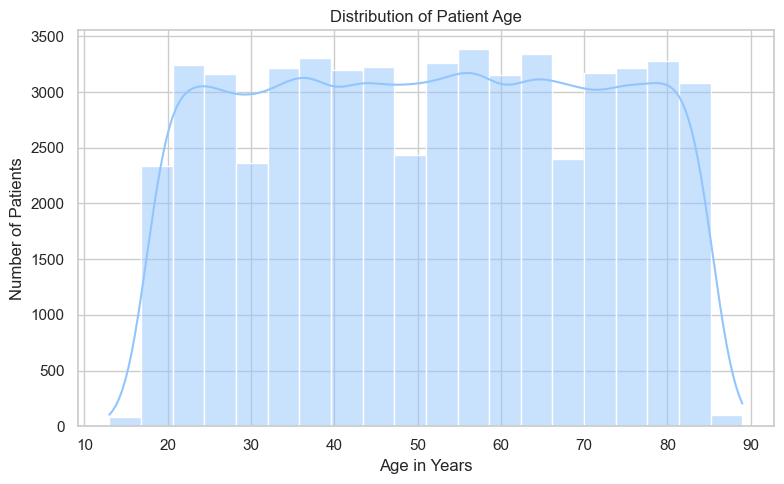

,Patient Count
Gender,
Male,27496
Female,27470


In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Age"], bins=20, kde=True, color=BLUE_3)
plt.title("Distribution of Patient Age")
plt.xlabel("Age in Years")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()
plt.close()

gender_counts = df["Gender"].value_counts()
gender_counts.to_frame(name="Patient Count")


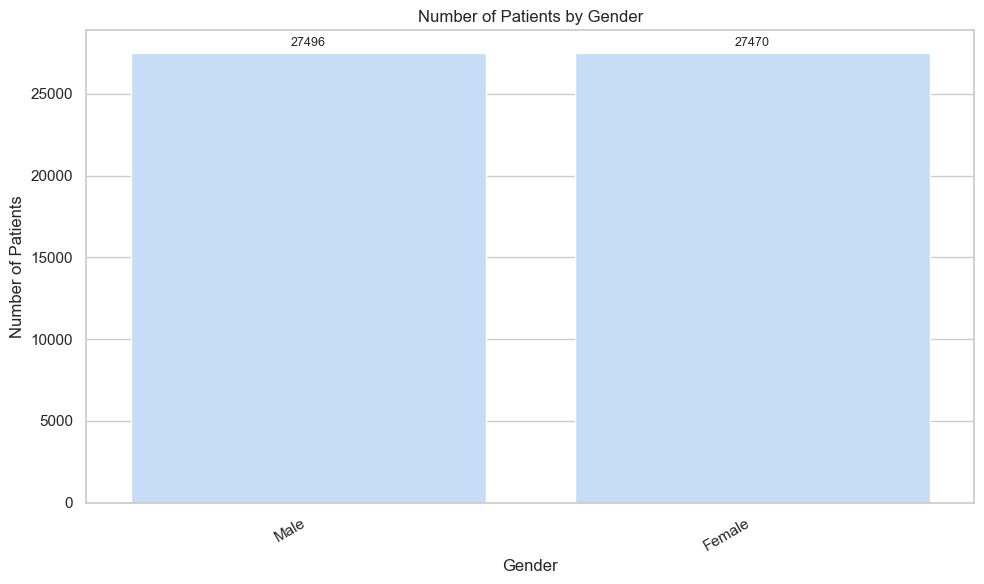

In [9]:
save_count_bar_plot(
    gender_counts,
    title="Number of Patients by Gender",
    xlabel="Gender",
    ylabel="Number of Patients",
    filename="gender_distribution.png",
    color=BLUE_2,
)


## 9. Medical Condition Mix
This section shows which medical conditions appear most frequently in the dataset.


In [10]:
condition_counts = df["Medical Condition"].value_counts()
condition_counts.to_frame(name="Number of Admissions")


,Number of Admissions
Medical Condition,
Arthritis,9218
Diabetes,9216
Hypertension,9151
Obesity,9146
Cancer,9140
Asthma,9095


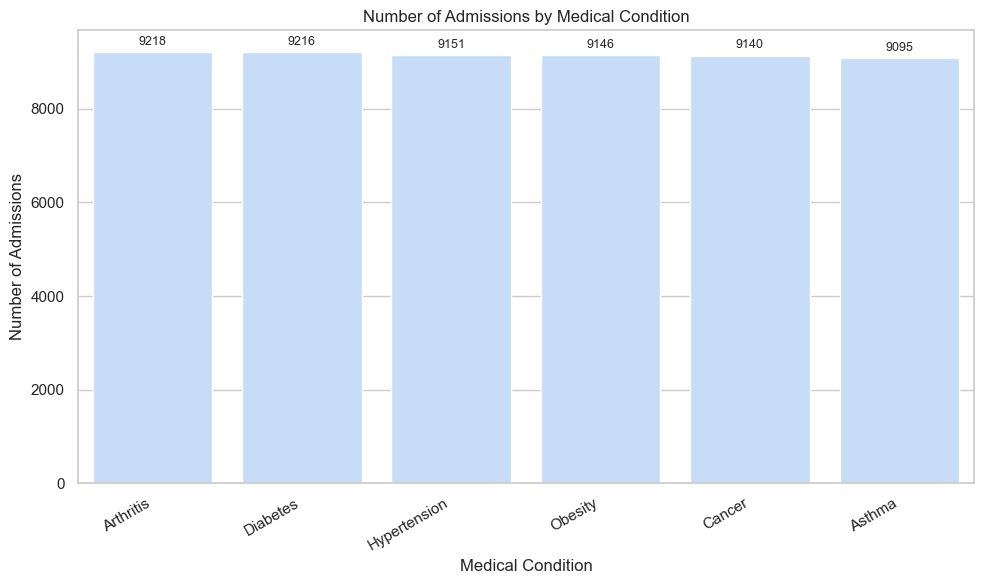

In [11]:
save_count_bar_plot(
    condition_counts,
    title="Number of Admissions by Medical Condition",
    xlabel="Medical Condition",
    ylabel="Number of Admissions",
    filename="condition_counts.png",
    color=BLUE_2,
)


## 10. Billing by Medical Condition
Average billing amount is compared across conditions to see which categories are associated with higher charges.


In [12]:
billing_by_condition = df.groupby("Medical Condition")["Billing Amount"].mean().sort_values(ascending=False).round(2)
billing_by_condition.to_frame(name="Average Billing Amount")


,Average Billing Amount
Medical Condition,
Obesity,"25,804.36"
Diabetes,"25,660.48"
Asthma,"25,633.46"
Arthritis,"25,511.78"
Hypertension,"25,503.06"
Cancer,"25,152.32"


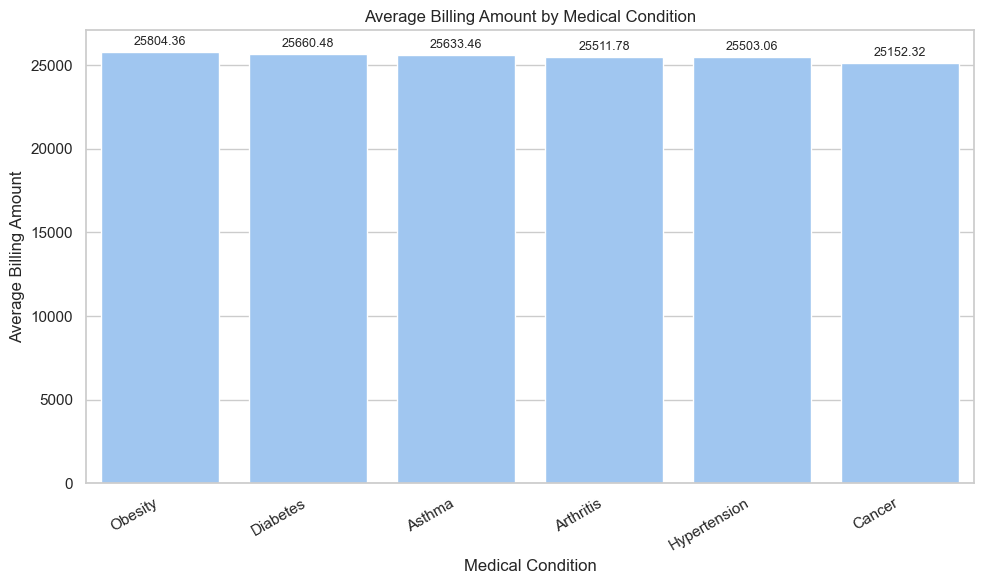

In [13]:
save_vertical_bar_plot(
    billing_by_condition,
    title="Average Billing Amount by Medical Condition",
    xlabel="Medical Condition",
    ylabel="Average Billing Amount",
    filename="billing_by_condition.png",
    color=BLUE_3,
)


## 11. Length of Stay by Medical Condition
Average length of stay is compared across conditions to identify categories that tend to remain in hospital longer.


In [14]:
stay_by_condition = df.groupby("Medical Condition")["Length of Stay"].mean().sort_values(ascending=False).round(2)
stay_by_condition.to_frame(name="Average Length of Stay")


,Average Length of Stay
Medical Condition,
Asthma,15.68
Arthritis,15.50
Cancer,15.50
Obesity,15.45
Hypertension,15.44
Diabetes,15.43


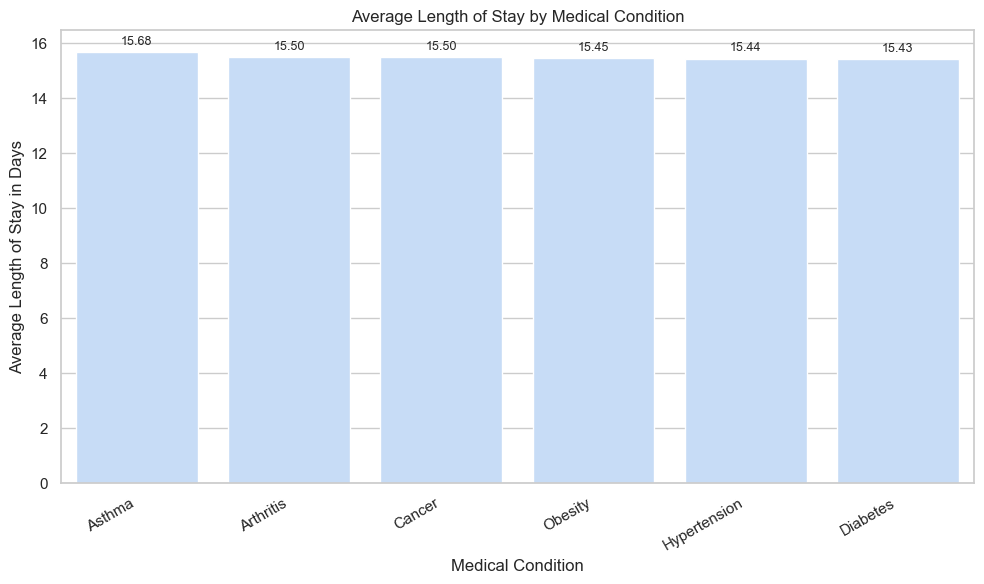

In [15]:
save_vertical_bar_plot(
    stay_by_condition,
    title="Average Length of Stay by Medical Condition",
    xlabel="Medical Condition",
    ylabel="Average Length of Stay in Days",
    filename="stay_by_condition.png",
    color=BLUE_2,
)


## 12. Billing and Length of Stay by Admission Type
Admission type is important operationally, so both average billing amount and average stay length are reviewed.


In [16]:
billing_by_admission = df.groupby("Admission Type")["Billing Amount"].mean().sort_values(ascending=False).round(2)
stay_by_admission = df.groupby("Admission Type")["Length of Stay"].mean().sort_values(ascending=False).round(2)

display(billing_by_admission.to_frame(name="Average Billing Amount"))
display(stay_by_admission.to_frame(name="Average Length of Stay"))


,Average Billing Amount
Admission Type,
Elective,"25,612.14"
Urgent,"25,514.53"
Emergency,"25,505.33"


,Average Length of Stay
Admission Type,
Emergency,15.58
Elective,15.51
Urgent,15.40


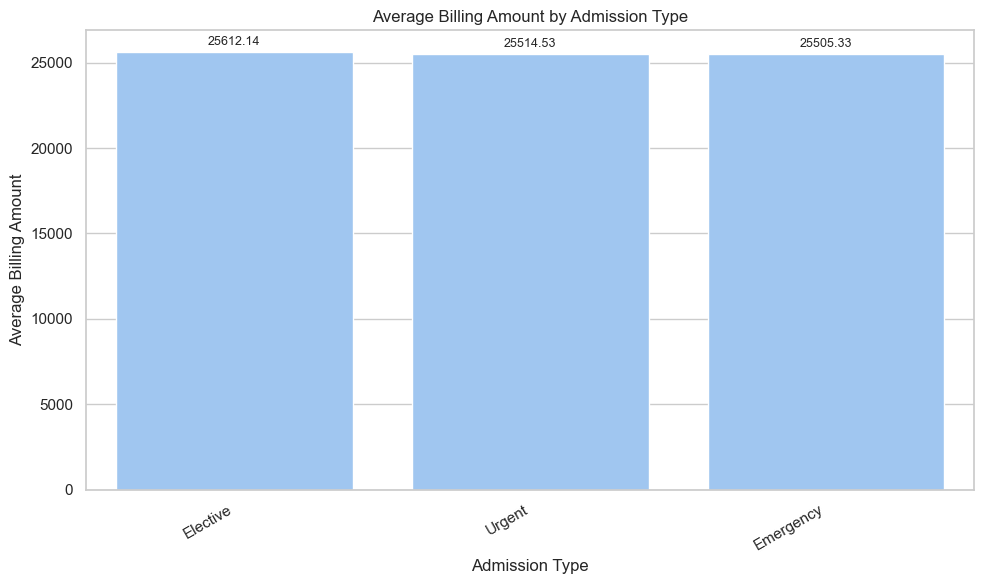

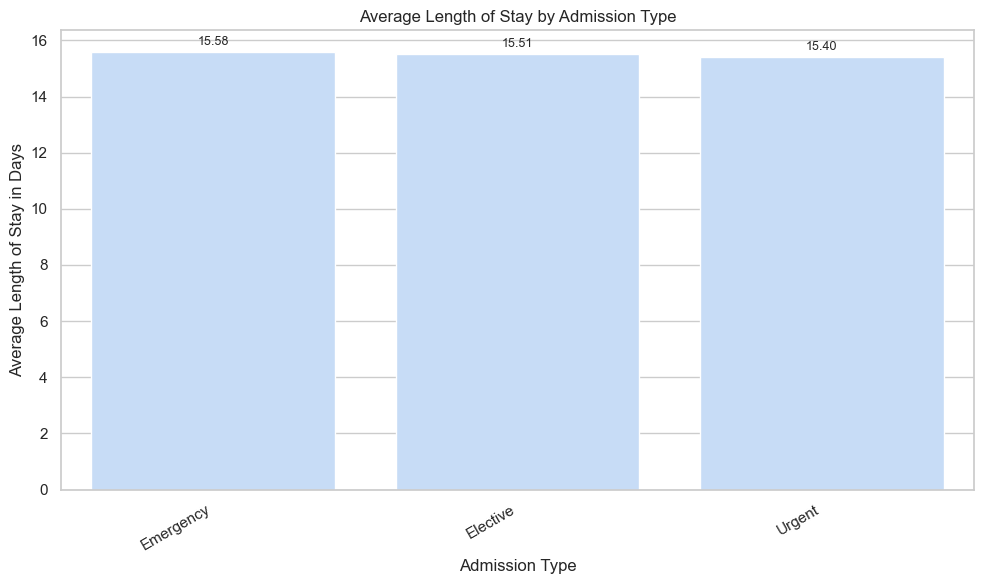

In [17]:
save_vertical_bar_plot(
    billing_by_admission,
    title="Average Billing Amount by Admission Type",
    xlabel="Admission Type",
    ylabel="Average Billing Amount",
    filename="billing_by_admission_type.png",
    color=BLUE_3,
)

save_vertical_bar_plot(
    stay_by_admission,
    title="Average Length of Stay by Admission Type",
    xlabel="Admission Type",
    ylabel="Average Length of Stay in Days",
    filename="stay_by_admission_type.png",
    color=BLUE_2,
)


## 13. Insurance Provider Analysis
This section compares insurance providers by average billing amount and average length of stay.


In [18]:
billing_by_insurance = df.groupby("Insurance Provider")["Billing Amount"].mean().sort_values(ascending=False).round(2)
stay_by_insurance = df.groupby("Insurance Provider")["Length of Stay"].mean().sort_values(ascending=False).round(2)

display(billing_by_insurance.to_frame(name="Average Billing Amount"))
display(stay_by_insurance.to_frame(name="Average Length of Stay"))


,Average Billing Amount
Insurance Provider,
Medicare,"25,628.32"
Blue Cross,"25,603.46"
Aetna,"25,549.69"
Cigna,"25,526.00"
UnitedHealthcare,"25,414.51"


,Average Length of Stay
Insurance Provider,
Medicare,15.62
Blue Cross,15.51
Cigna,15.48
Aetna,15.44
UnitedHealthcare,15.44


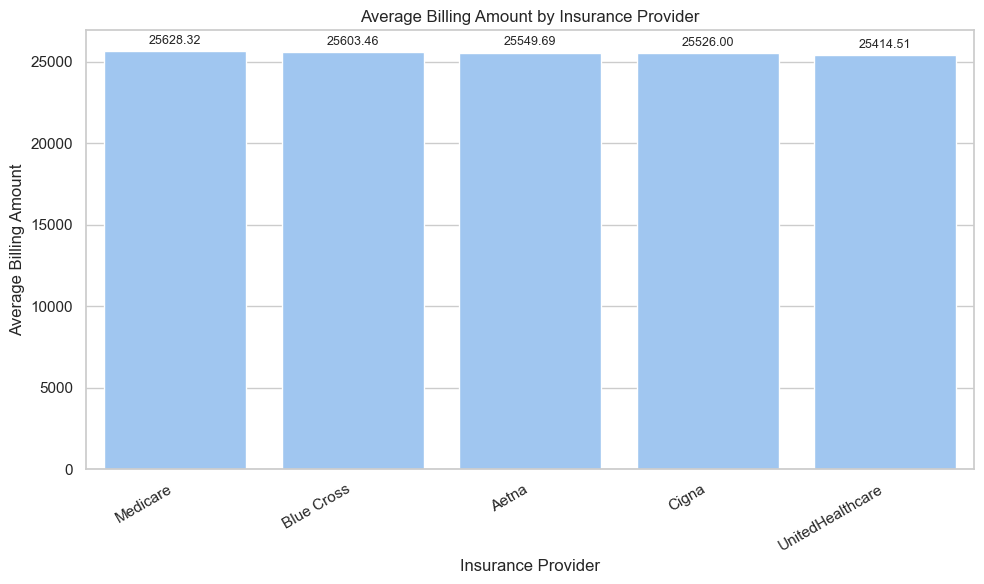

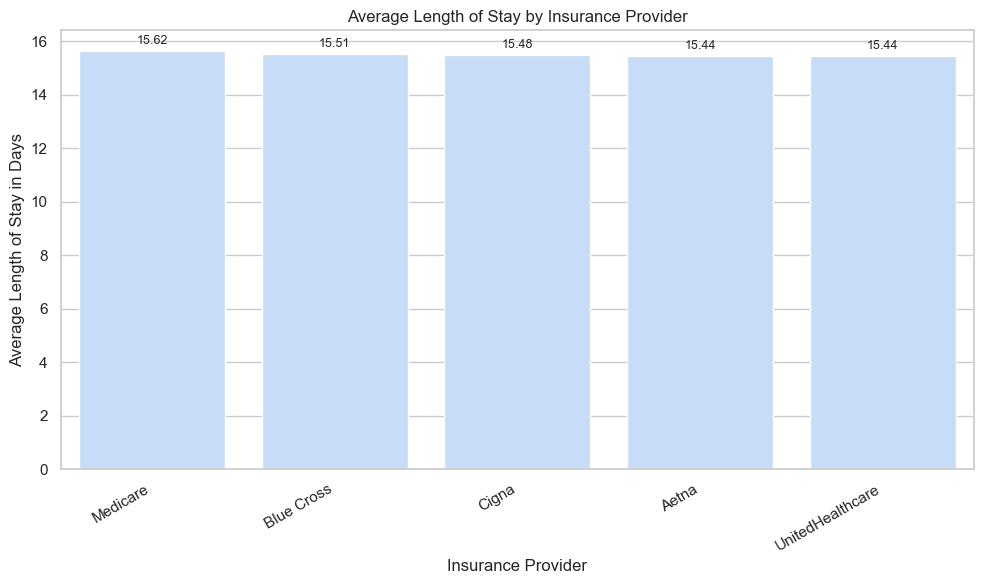

In [19]:
save_vertical_bar_plot(
    billing_by_insurance,
    title="Average Billing Amount by Insurance Provider",
    xlabel="Insurance Provider",
    ylabel="Average Billing Amount",
    filename="billing_by_insurance.png",
    color=BLUE_3,
)

save_vertical_bar_plot(
    stay_by_insurance,
    title="Average Length of Stay by Insurance Provider",
    xlabel="Insurance Provider",
    ylabel="Average Length of Stay in Days",
    filename="stay_by_insurance.png",
    color=BLUE_2,
)


## 14. Test Result Patterns
The distribution of test results and their relationship to billing amount and length of stay are examined here.


In [20]:
test_result_counts = df["Test Results"].value_counts()
billing_by_test_result = df.groupby("Test Results")["Billing Amount"].mean().sort_values(ascending=False).round(2)
stay_by_test_result = df.groupby("Test Results")["Length of Stay"].mean().sort_values(ascending=False).round(2)

display(test_result_counts.to_frame(name="Number of Records"))
display(billing_by_test_result.to_frame(name="Average Billing Amount"))
display(stay_by_test_result.to_frame(name="Average Length of Stay"))


,Number of Records
Test Results,
Abnormal,18437
Normal,18331
Inconclusive,18198


,Average Billing Amount
Test Results,
Inconclusive,"25,637.34"
Abnormal,"25,544.04"
Normal,"25,452.22"


,Average Length of Stay
Test Results,
Normal,15.54
Abnormal,15.51
Inconclusive,15.45


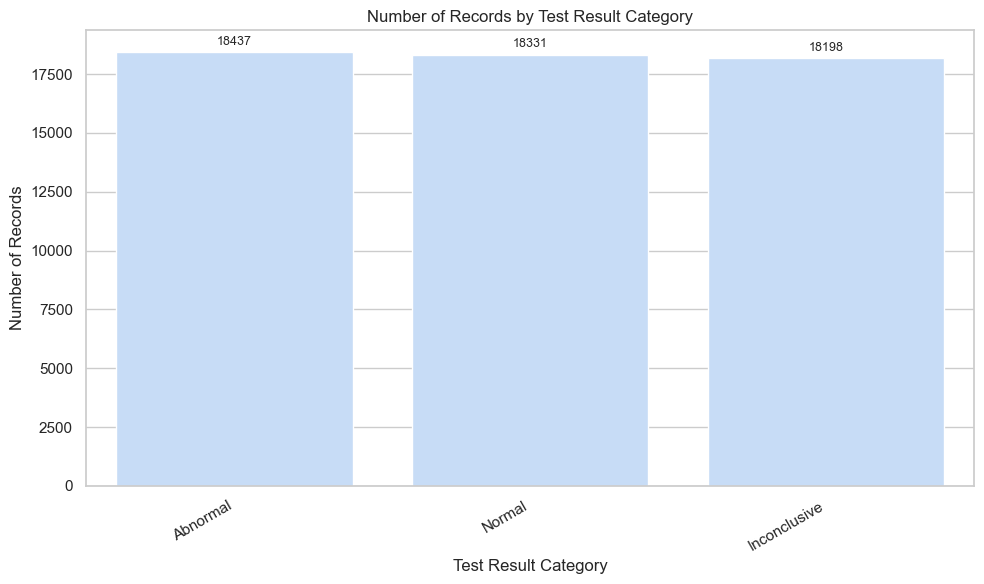

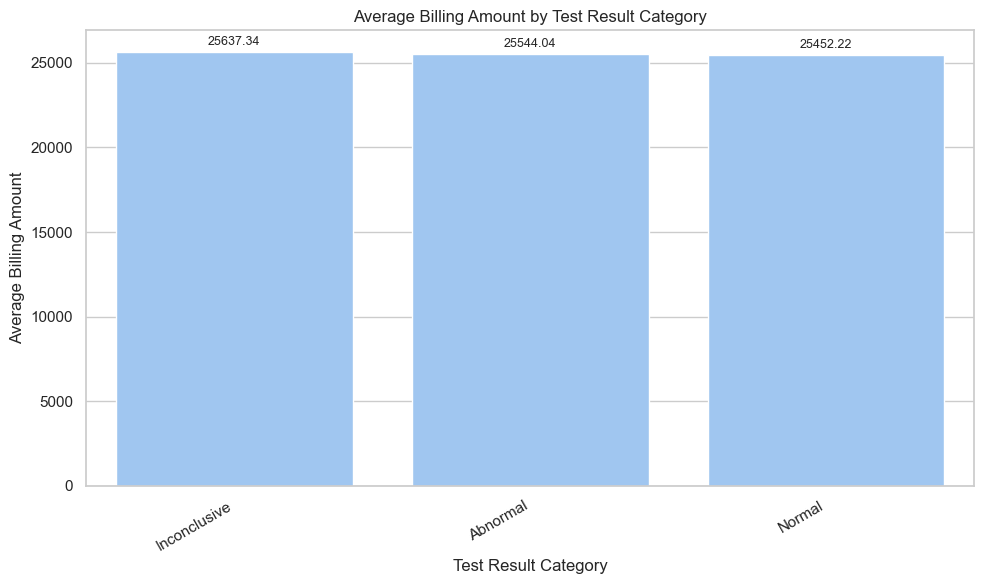

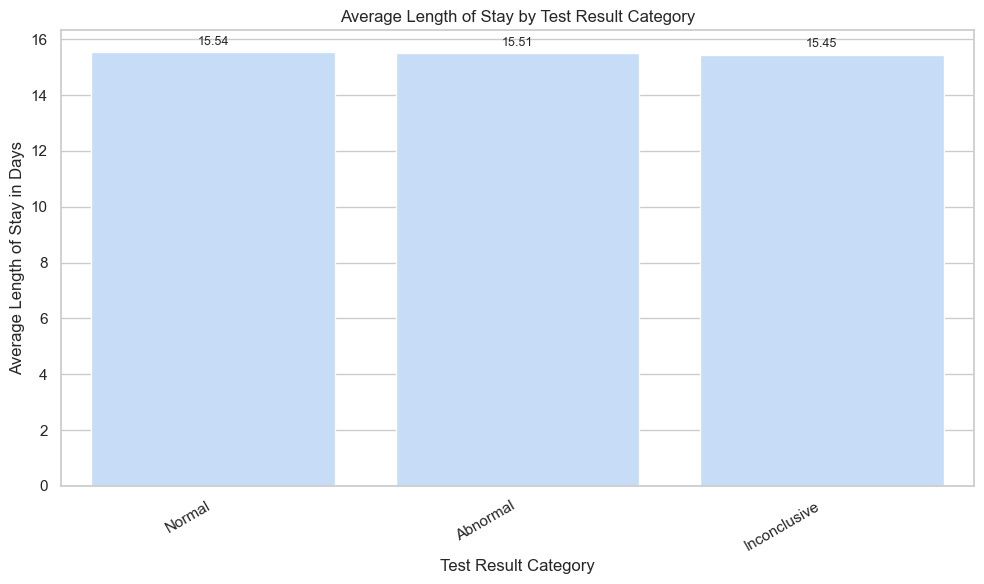

In [21]:
save_count_bar_plot(
    test_result_counts,
    title="Number of Records by Test Result Category",
    xlabel="Test Result Category",
    ylabel="Number of Records",
    filename="test_result_counts.png",
    color=BLUE_2,
)

save_vertical_bar_plot(
    billing_by_test_result,
    title="Average Billing Amount by Test Result Category",
    xlabel="Test Result Category",
    ylabel="Average Billing Amount",
    filename="billing_by_test_result.png",
    color=BLUE_3,
)

save_vertical_bar_plot(
    stay_by_test_result,
    title="Average Length of Stay by Test Result Category",
    xlabel="Test Result Category",
    ylabel="Average Length of Stay in Days",
    filename="stay_by_test_result.png",
    color=BLUE_2,
)


## 15. Medication Frequency
The medication frequency table and chart show which drugs appear most often in the dataset.


In [22]:
medication_counts = df["Medication"].value_counts().sort_values(ascending=False)
medication_counts.to_frame(name="Number of Prescriptions")


,Number of Prescriptions
Medication,
Lipitor,11038
Ibuprofen,11023
Aspirin,10984
Paracetamol,10965
Penicillin,10956


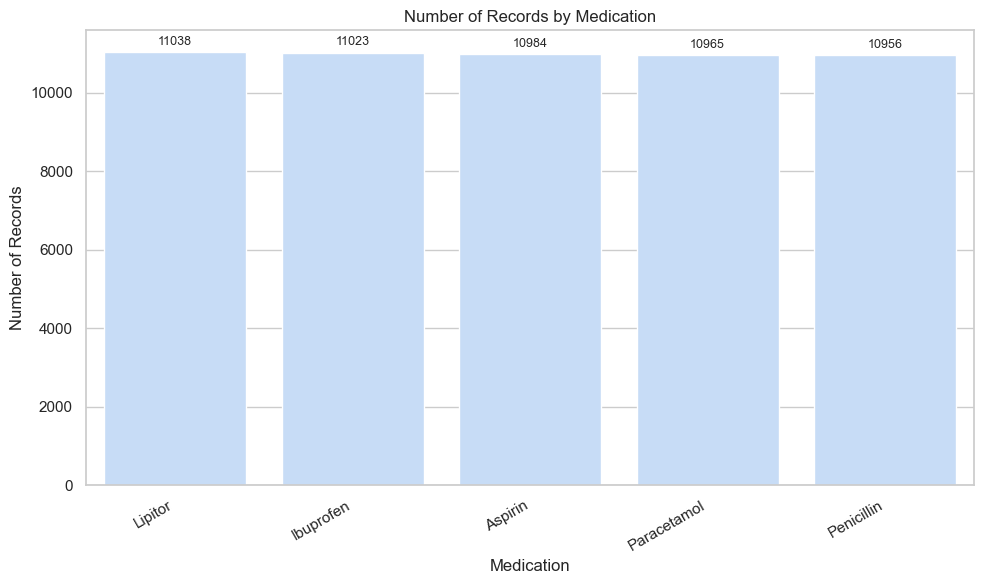

In [23]:
save_count_bar_plot(
    medication_counts,
    title="Number of Records by Medication",
    xlabel="Medication",
    ylabel="Number of Records",
    filename="medication_counts.png",
    color=BLUE_2,
)


## 16. Monthly and Yearly Admission Trends
Trend analysis helps show whether hospital admissions are stable over time or concentrated in specific periods.


In [24]:
monthly = (
    df.groupby("Admission Month")
    .agg(admissions=("Name", "size"))
    .reset_index()
    .sort_values("Admission Month")
)

yearly = (
    df.groupby("Admission Year")
    .agg(admissions=("Name", "size"))
    .reset_index()
    .sort_values("Admission Year")
)

display(monthly.head())
display(yearly)


,Admission Month,admissions
0,2019-05,677
1,2019-06,899
2,2019-07,951
3,2019-08,985
4,2019-09,924


,Admission Year,admissions
0,2019,7300
1,2020,11172
2,2021,10816
3,2022,10915
4,2023,10936
5,2024,3827


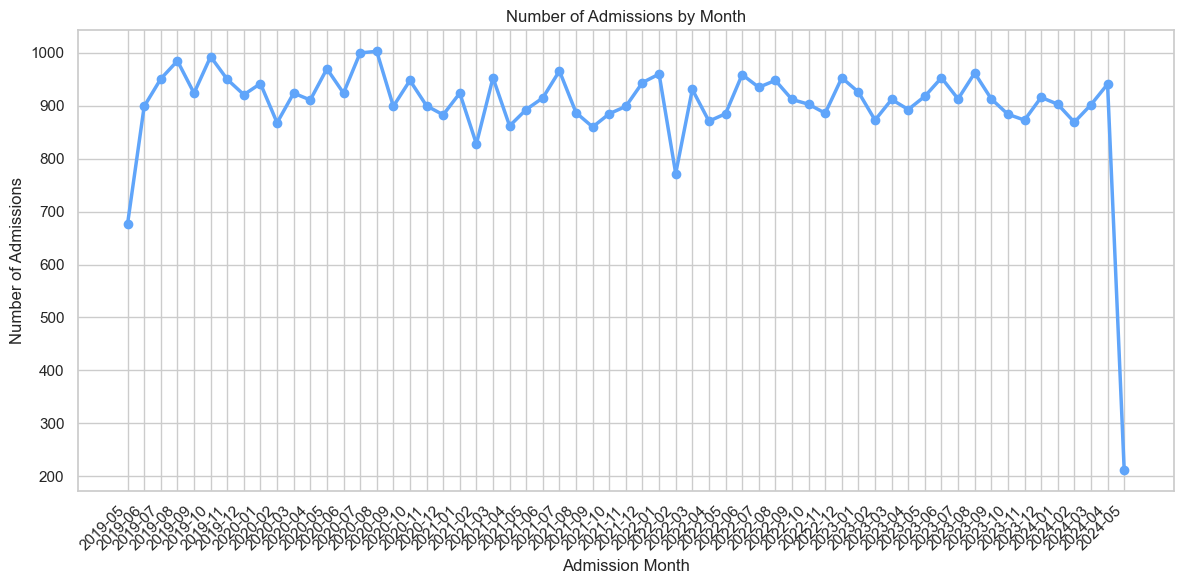

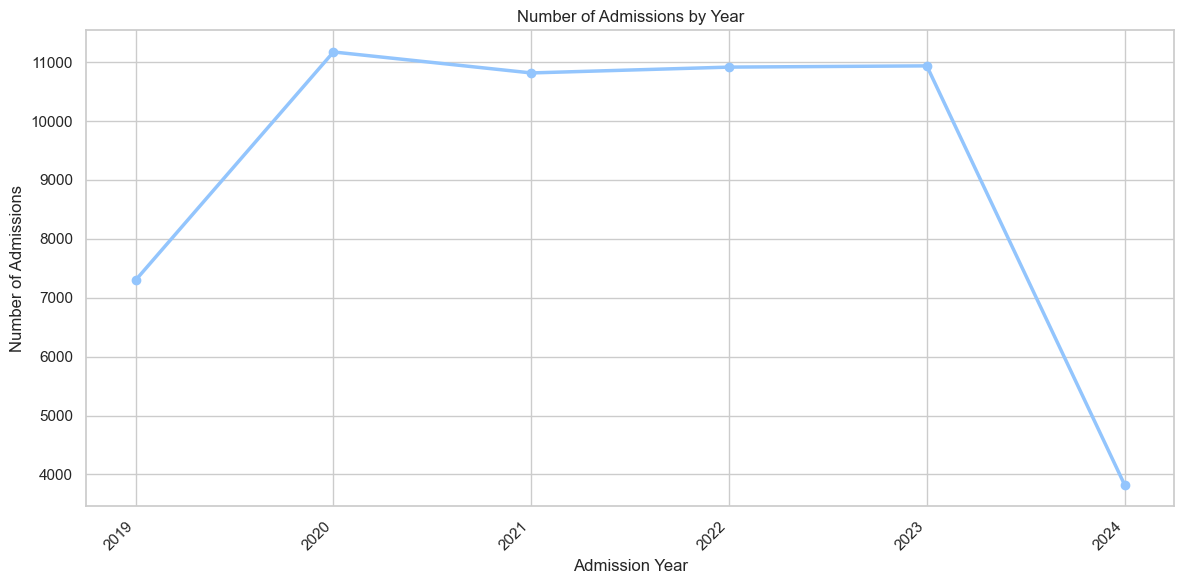

In [25]:
save_line_plot(
    monthly,
    x_col="Admission Month",
    y_col="admissions",
    title="Number of Admissions by Month",
    xlabel="Admission Month",
    ylabel="Number of Admissions",
    filename="monthly_admissions.png",
    color=BLUE_4,
)

save_line_plot(
    yearly,
    x_col="Admission Year",
    y_col="admissions",
    title="Number of Admissions by Year",
    xlabel="Admission Year",
    ylabel="Number of Admissions",
    filename="yearly_admissions.png",
    color=BLUE_3,
)


## 17. Correlation Analysis
A correlation table and heatmap are used to check whether age, billing amount, and length of stay move together in a linear way.


In [26]:
corr_df = df[["Age", "Billing Amount", "Length of Stay"]].corr().round(4)
corr_df


,Age,Billing Amount,Length of Stay
Age,1.00,-0.00,0.01
Billing Amount,-0.00,1.00,-0.00
Length of Stay,0.01,-0.00,1.00


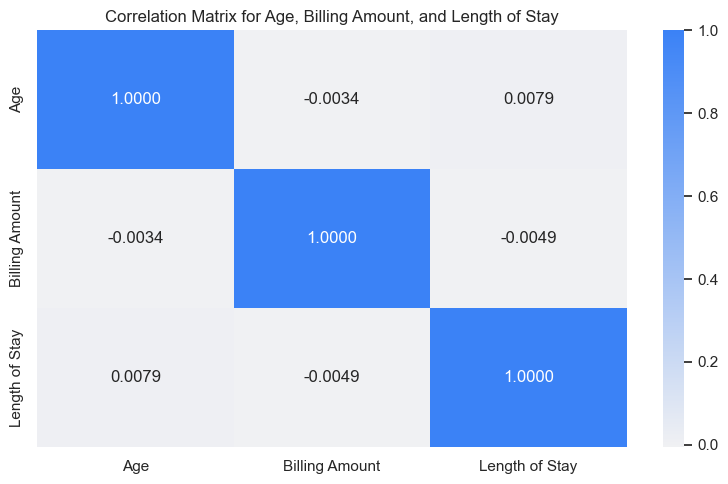

In [27]:
save_heatmap(
    corr_df,
    title="Correlation Matrix for Age, Billing Amount, and Length of Stay",
    filename="correlation_heatmap.png",
)


## 18. Key Findings
The analysis suggests that the dataset has a highly balanced structure across most of its major categories. Patient demographics are evenly distributed, the most common medical conditions appear in similar proportions, and medication counts do not show extreme concentration in any one category. This makes the dataset particularly useful for comparative descriptive analysis because no single segment overwhelms the others.

From a financial perspective, the average billing amount changes slightly across medical conditions, admission types, insurance providers, and test-result categories, but the variation is not especially large. Some groups, such as patients with obesity, appear to have somewhat higher average billing amounts, while other categories remain close to the overall mean. This suggests that cost patterns exist, but they are relatively moderate rather than sharply divided.

The length-of-stay analysis tells a similar story. Emergency admissions tend to stay a little longer on average, and some medical conditions are associated with slightly longer hospitalization periods, but the overall spread remains narrow. Insurance-provider differences in both billing and stay length are also small, which implies that payer type is not a strong separator in this dataset.

The time-based analysis shows that admissions rise and fall over months and years, but without a dramatic long-term shift. Finally, the correlation analysis indicates that age, billing amount, and length of stay have very weak linear relationships with one another. Taken together, these findings show that the dataset is strongest as a tool for exploratory insight and reporting, especially for identifying subtle operational patterns rather than strong predictive signals.


## 19. Conclusion
The analysis shows that this healthcare dataset is clean, balanced, and well suited for descriptive reporting. Patient ages are broadly distributed, the gender split is nearly even, and the major medical conditions appear in fairly similar proportions, which makes comparisons across groups straightforward.

In terms of cost, average billing amounts vary across medical conditions, admission types, insurance providers, and test-result categories, but the differences are generally modest. Obesity appears among the highest-cost conditions on average, while emergency admissions tend to have slightly longer stays than other admission types. Insurance providers and test-result categories show some variation as well, but not enough to suggest strong separation between groups.

The time-based analysis suggests that admissions fluctuate from month to month and year to year without a dramatic long-term shift. Medication and condition counts are also relatively even, reinforcing the impression that the dataset is quite standardized. Finally, the correlation analysis shows that age, billing amount, and length of stay have very weak linear relationships with one another, which means that no single variable strongly explains the others in a simple way.

Overall, the key insight from this analysis is that the dataset is most useful for exploratory and descriptive healthcare reporting. It highlights small but meaningful operational differences across categories while also showing that most patterns remain relatively stable across the population.
